In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
# all the dependencies
import gym
from ray.rllib.algorithms.sac import SACConfig
from ray.rllib.algorithms.algorithm import Algorithm
from ray.tune.logger import pretty_print
import numpy as np
import os
import pandas as pd
import matplotlib as plt

C:\Users\ritwi\anaconda3\envs\ray\lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


In [3]:
# name of the environment
env_name = "CartPole-v1"
env = gym.make("CartPole-v1", render_mode='human')  # import the Lunar Lander environment

In [ ]:
.training(n_step=250,
              gamma=0.99,
              model = {'vf_share_layers': False},
              q_model_config = {'fcnet_hiddens': [256, 256],
                                'fcnet_activation': 'relu',
                               },
              policy_model_config = {'fcnet_hiddens': [256, 256],
                                     'fcnet_activation': 'relu'
                                    }
             )

In [13]:
# Configuring an Agent: This agent use Defatlt settings from RayRLlib 
# Name: agent_default

config = (
    # The RL algorithm
    SACConfig()                       
    # The gym Env
    .environment(env_name)           
    # Numbers of rollout workers
    .rollouts(num_rollout_workers = 1)
    # Use "torch" for using pytorch or "tf" or "tf2" for Tensor Flow. "tf2" is not working for the time being.
    .framework("tf")
    # Numbers of evalution workers
    .evaluation(evaluation_num_workers=1)
    
)

#Building the agent with the configurations mentioned above
agent = config.build()
check_point = "SAC_agents/0"
agent.save(check_point)

2024-04-08 22:25:03,099	WARNING algorithm_config.py:3824 -- You have specified 1 evaluation workers, but your `evaluation_interval` is None! Therefore, evaluation will not occur automatically with each call to `Algorithm.train()`. Instead, you will have to call `Algorithm.evaluate()` manually in order to trigger an evaluation run.
(pid=18756) C:\Users\ritwi\anaconda3\envs\ray\lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
(pid=18756)   "class": algorithms.Blowfish,
2024-04-08 22:25:18,728	WARNING algorithm_config.py:3824 -- You have specified 1 evaluation workers, but your `evaluation_interval` is None! Therefore, evaluation will not occur automatically with each call to `Algorithm.train()`. Instead, you will have to call `Algorithm.evaluate()` manually in order to trigger an evaluation run.
(pid=5176) C:\Users\ritwi\anaconda3\envs\ray\lib\site-packages\paramiko\transport.py:219: Cryptogr

TrainingResult(checkpoint=Checkpoint(filesystem=local, path=SAC_agents/0), metrics={})

In [15]:
if os.path.exists('SAC_logs') is False:
    os.mkdir('SAC_logs/')

if os.path.exists('SAC_logs/logs') is False:
    columns = ['agent_name','itr_steps','rew_mean','rew_max','rew_min']
    df = pd.DataFrame(columns=columns)
    df.to_csv('SAC_logs/logs', index=False)
    print(df)

Empty DataFrame
Columns: [agent_name, itr_steps, rew_mean, rew_max, rew_min]
Index: []


In [14]:
# Recall the last trained agent
agent_name_list = os.listdir('SAC_agents')
agent_name_list_in_int = [int(x) for x in agent_name_list]
last_agent_num = max(agent_name_list_in_int)
check_point = 'SAC_agents/' + str(last_agent_num)
agent = Algorithm.from_checkpoint(check_point)
result = agent.train()
result

2024-04-08 22:26:07,534	WARNING algorithm_config.py:3824 -- You have specified 1 evaluation workers, but your `evaluation_interval` is None! Therefore, evaluation will not occur automatically with each call to `Algorithm.train()`. Instead, you will have to call `Algorithm.evaluate()` manually in order to trigger an evaluation run.
(pid=22044) C:\Users\ritwi\anaconda3\envs\ray\lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
(pid=22044)   "class": algorithms.Blowfish,
2024-04-08 22:26:20,799	WARNING algorithm_config.py:3824 -- You have specified 1 evaluation workers, but your `evaluation_interval` is None! Therefore, evaluation will not occur automatically with each call to `Algorithm.train()`. Instead, you will have to call `Algorithm.evaluate()` manually in order to trigger an evaluation run.
(pid=1652) C:\Users\ritwi\anaconda3\envs\ray\lib\site-packages\paramiko\transport.py:219: Cryptogr

{'custom_metrics': {},
 'episode_media': {},
 'info': {'learner': {},
  'num_env_steps_sampled': 100,
  'num_env_steps_trained': 0,
  'num_agent_steps_sampled': 100,
  'num_agent_steps_trained': 0},
 'sampler_results': {'episode_reward_max': 17.0,
  'episode_reward_min': 11.0,
  'episode_reward_mean': 13.25,
  'episode_len_mean': 13.25,
  'episode_media': {},
  'episodes_this_iter': 4,
  'policy_reward_min': {},
  'policy_reward_max': {},
  'policy_reward_mean': {},
  'custom_metrics': {},
  'hist_stats': {'episode_reward': [11.0, 12.0, 13.0, 17.0],
   'episode_lengths': [11, 12, 13, 17]},
  'sampler_perf': {'mean_raw_obs_processing_ms': 1.695104164652305,
   'mean_inference_ms': 1.7856961429709255,
   'mean_action_processing_ms': 0.22463515253350286,
   'mean_env_wait_ms': 0.1645017378401048,
   'mean_env_render_ms': 0.0},
  'num_faulty_episodes': 0,
  'connector_metrics': {'ObsPreprocessorConnector_ms': 0.0,
   'StateBufferConnector_ms': 0.0,
   'ViewRequirementAgentConnector_ms': 0.

In [18]:
result['info']['learner']

{'default_policy': {'learner_stats': {'mean_td_error': 1.4578708,
   'actor_loss': -10.852751,
   'critic_loss': 0.11644995,
   'alpha_loss': -0.041769948,
   'alpha_value': 1.4662719,
   'target_entropy': 0.6792842388153076,
   'mean_q': 9.628625,
   'max_q': 16.189915,
   'min_q': 0.80801785,
   'model': {}},
  'td_error': array([2.13775635e-02, 5.97677803e+00, 2.06423759e-01, 7.85895109e-01,
         3.49603176e-01, 1.05348377e+01, 1.72724724e-01, 1.89931393e-01,
         9.65657234e-02, 8.26611757e-01, 9.62380886e-01, 7.89801836e-01,
         5.52722120e+00, 1.95928597e+00, 6.79658175e-01, 3.24439049e-01,
         1.54914570e+00, 2.81079292e-01, 9.37647820e-02, 2.01270103e-01,
         8.45313072e-01, 2.74735928e-01, 2.54074097e-01, 7.87400198e+00,
         9.57298279e-02, 7.10424519e+00, 4.88052368e-02, 8.96898031e-01,
         9.23098803e-01, 8.96898031e-01, 3.83140469e+00, 4.17351723e-01,
         6.42461777e-02, 1.47896290e-01, 1.62985802e-01, 2.37969255e+00,
         1.9291067

In [21]:
# Recall the last trained agent
agent_name_list = os.listdir('SAC_agents')
agent_name_list_in_int = [int(x) for x in agent_name_list]
last_agent_num = max(agent_name_list_in_int)
check_point = 'SAC_agents/' + str(last_agent_num)
agent = Algorithm.from_checkpoint(check_point)

# Recall the log data frame
logs = pd.read_csv('SAC_logs/logs')

training_range = 2000

for i in range(last_agent_num, (last_agent_num + training_range)):
    # Train the agent
    result = agent.train()
    # Save the agent
    check_point_path_name = 'SAC_agents/' + str(i+1)
    agent.save(check_point_path_name)
    # Capture the log    
    #print(pretty_print(result)) # It gives all the parameters regarding the training
    logs.at[i,'agent_name'] = str(i+1)
    logs.at[i,'itr_steps'] = result['num_agent_steps_sampled'] * (i+1)
    logs.at[i,'rew_mean'] = result['episode_reward_mean']
    logs.at[i,'rew_max'] = result['episode_reward_max']
    logs.at[i,'rew_min'] = result['episode_reward_min']
    
    #print(logs)
    logs.to_csv('SAC_logs/logs', index=False)

2024-04-08 22:48:26,560	WARNING algorithm_config.py:3824 -- You have specified 1 evaluation workers, but your `evaluation_interval` is None! Therefore, evaluation will not occur automatically with each call to `Algorithm.train()`. Instead, you will have to call `Algorithm.evaluate()` manually in order to trigger an evaluation run.
C:\Users\ritwi\anaconda3\envs\ray\lib\site-packages\ray\rllib\algorithms\algorithm.py:500: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
C:\Users\ritwi\anaconda3\envs\ray\lib\site-packages\ray\tune\logger\unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger in

KeyboardInterrupt: 

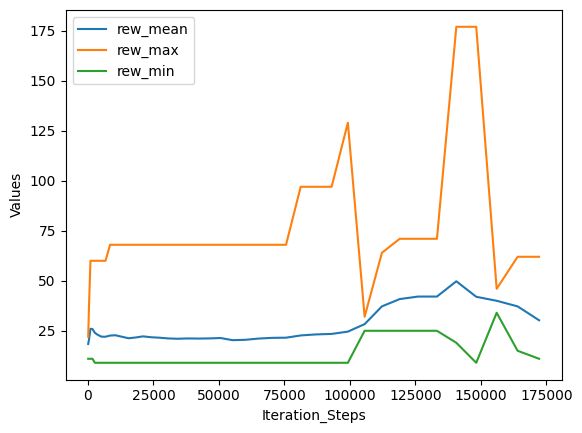

In [22]:
import matplotlib.pyplot as plt
logs = pd.read_csv('SAC_logs/logs')

# Plotting Column1 and Column2 with Time as the x-axis
plt.plot(logs['itr_steps'], logs['rew_mean'], label='rew_mean')
plt.plot(logs['itr_steps'], logs['rew_max'], label='rew_max')
plt.plot(logs['itr_steps'], logs['rew_min'], label='rew_min')

# Adding labels and legend
plt.xlabel('Iteration_Steps')
plt.ylabel('Values')
plt.legend()

# Display the plot
plt.show()


In [29]:
# recall and trained agent
check_point = "SAC_agents/2110"
agent = Algorithm.from_checkpoint(check_point)

2024-04-07 22:32:23,902	WARNING algorithm_config.py:3824 -- You have specified 1 evaluation workers, but your `evaluation_interval` is None! Therefore, evaluation will not occur automatically with each call to `Algorithm.train()`. Instead, you will have to call `Algorithm.evaluate()` manually in order to trigger an evaluation run.
C:\Users\ritwi\anaconda3\envs\ray\lib\site-packages\ray\rllib\algorithms\algorithm.py:500: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
C:\Users\ritwi\anaconda3\envs\ray\lib\site-packages\ray\tune\logger\unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger in

In [45]:
# use the restored agent in the environment
env = gym.make("CartPole-v1", render_mode='human')
for j in range(20):
    observation = np.array(env.reset()[0])
    done = False
    score = 0
    while not done:
        action = agent.compute_single_action(observation) # here is the RL agent from RAYRLlib
        observation,reward,done,info,info = env.step(action)
        score += reward
        if (score>1000):
            done = True
    print("score:",score)
env.close()

C:\Users\ritwi\anaconda3\envs\ray\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


score: 291.0
score: 481.0
score: 325.0
score: 310.0
score: 245.0
score: 351.0
score: 424.0
score: 254.0
score: 263.0
score: 299.0
score: 324.0
score: 135.0
score: 309.0
score: 268.0
score: 353.0
score: 333.0
score: 227.0
score: 228.0
score: 338.0
score: 241.0
